**🌐 Language:** [English →](/rdd-basic-en) | **한국어**

# Regression Discontinuity Design (RDD)

<small><em>작성자 손지우 · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)
warnings.filterwarnings('ignore')

## 1. RDD란 무엇인가?

수능이 끝나고 결과가 나왔습니다. 장학금 기준은 70점. 69점을 받은 학생과 71점을 받은 학생은 딱 2점 차이밖에 나지 않습니다. 실력 차이라기보다는 그날의 컨디션이나 운이 결과를 갈라놓은 것에 가깝습니다. 그런데 한 명은 장학금을 받고, 다른 한 명은 받지 못합니다.

이 상황을 거꾸로 생각해봅시다. 장학금이 이후 학업 성취도에 미치는 인과 효과를 알고 싶다면, 가장 이상적인 비교 대상은 누구일까요? 바로 이 두 학생입니다. 기준 점수 바로 위와 아래에 있는 학생들은 장학금 수혜 여부를 제외하면 사실상 동등한 조건에 있습니다.

이것이 **RDD(Regression Discontinuity Design)**의 핵심 아이디어입니다.

어떤 특정 기준점(cutoff)을 넘는지 여부로 처치(정책, 혜택 등)가 결정될 때, 그 기준점 바로 근방의 개체들을 비교해 인과 효과를 추정하는 방법입니다. RCT처럼 무작위 배정을 하지 않았지만, 기준점 근방에서는 마치 무작위 배정에 가까운 상황이 만들어집니다.

현실에서 RDD를 적용할 수 있는 상황은 생각보다 많습니다.

| 상황 | Running Variable | Cutoff | Treatment |
|------|-----------------|--------|-----------|
| 장학금 기준 점수 | 수능 점수 | 70점 | 장학금 수혜 |
| 복지 수급 자격 | 소득 수준 | 기준 중위소득 50% | 급여 지원 |
| 음주 허용 나이 | 나이 | 만 19세 | 주류 구매 허용 |
| 의약품 보험 적용 | 약가 | 특정 기준 가격 | 보험 급여 적용 |

이처럼 RDD는 "명확한 규칙으로 처치가 결정되는" 상황이라면 어디서든 적용을 고려해볼 수 있습니다.

## 2. RDD 종류

RDD는 크게 Sharp Design과 Fuzzy Design으로 나뉩니다.

* `Sharp Design`: 임계값을 기준으로 처치 여부가 완전히 결정되는 경우
* `Fuzzy Design`: 임계값이 처치 확률에는 영향을 주지만 실제 처치 여부가 완전히 일치하지는 않는 경우

예를 들어 장학금 기준 점수를 넘으면 반드시 장학금을 받는다면 Sharp, 넘어도 신청하지 않거나 심사에서 탈락할 수 있다면 Fuzzy입니다. 이 장에서는 Sharp RDD를 중심으로 다루며, Fuzzy RDD는 별도 챕터에서 자세히 설명합니다.

![rdd types](images/rdd_types.png)

## 3. 핵심 가정

RDD가 인과 효과를 제대로 추정하려면 중요한 가정 두 가지가 필요합니다.

### 연속성 가정 (Continuity Assumption)

첫 번째는 **잠재적 결과의 연속성**입니다. 장학금을 받지 않았을 때의 기대 GPA와, 받았을 때의 기대 GPA 모두 기준 점수 근방에서 매끄럽게 이어져야 한다는 뜻입니다.

$$\mathbb{E}[Y_i(0) \mid X_i = x] \quad \text{and} \quad \mathbb{E}[Y_i(1) \mid X_i = x] \quad \text{는 } x = c \text{ 에서 연속}$$

왜 이게 중요할까요? 만약 이 조건이 충족된다면, 기준 점수 근방에서 관측 결과에 나타나는 **갑작스러운 점프(discontinuity)** 는 오직 처치(장학금) 때문이라고 해석할 수 있습니다.

반대로 이 조건이 깨지면 어떻게 될까요? 예를 들어 학교에서 70점 전후 학생들만 선별해서 특별 지도를 제공한다면, 그 근방에서 GPA가 점프하는 것이 장학금 때문인지 특별 지도 때문인지 알 수 없게 됩니다.

### 국소 무작위화 (Local Randomization)

두 번째는 연속성 가정의 또 다른 표현입니다. 기준 점수 $c$ 아주 근방에서는, 69.5점을 받을지 70.5점을 받을지가 실질적으로 무작위에 가깝다는 것입니다.

이 논리가 성립하려면 개체가 기준점을 **의도적으로 넘을 수 없어야** 합니다. 만약 선생님이 특정 학생을 70점 이상으로 밀어주거나, 학생 스스로 70점을 겨냥해 점수를 관리한다면, 기준점 근방의 "준무작위성"은 사라지게 됩니다. 이것을 **조작(manipulation)** 이라 하며, 타당성 검정 과정에서 반드시 확인해야 합니다.

## 4. 구성 요소

RDD를 이해하려면 몇 가지 핵심 개념을 명확히 해야 합니다.

**Running Variable (실행 변수)** $X_i$는 처치 여부를 결정하는 연속형 변수입니다. 수능 점수, 나이, 소득 수준처럼 개체마다 값이 다르고, 이 값에 따라 처치를 받는지 여부가 결정됩니다. 중요한 것은 개체가 이 값을 정밀하게 조작할 수 없어야 한다는 점입니다.

**Cutoff (임계값)** $c$는 처치를 받는 기준입니다. Sharp RDD에서는 $X_i \geq c$면 반드시 처치를 받고, $X_i < c$면 받지 못합니다.

$$D_i = \mathbf{1}[X_i \geq c]$$

**잠재적 결과(Potential Outcomes)** 는 앞서 인과추론 챕터에서 다룬 그 개념 그대로입니다.

- $Y_i(1)$: 장학금을 받았을 때의 GPA
- $Y_i(0)$: 장학금을 받지 않았을 때의 GPA
- 실제 관측값: $Y_i^{obs} = D_i \cdot Y_i(1) + (1 - D_i) \cdot Y_i(0)$

한 학생의 $Y_i(1)$과 $Y_i(0)$을 동시에 볼 수는 없습니다. 장학금을 받은 학생은 $Y_i(1)$만, 받지 못한 학생은 $Y_i(0)$만 관측됩니다.

아래 표가 이 상황을 정리해줍니다.

In [2]:
pd.DataFrame({
    '학생': ['A', 'B', 'C', 'D'],
    'X (수능 점수)': [69, 70, 71, 75],
    'D (장학금 여부)': [0, 1, 1, 1],
    'Y(0) — 미수혜 GPA': [3.1, '?', '?', '?'],
    'Y(1) — 수혜 GPA': ['?', 3.6, 3.7, 3.9],
    '관측 GPA': [3.1, 3.6, 3.7, 3.9],
})

,학생,X (수능 점수),D (장학금 여부),Y(0) — 미수혜 GPA,Y(1) — 수혜 GPA,관측 GPA
0,A,69,0,3.1,?,3.1
1,B,70,1,?,3.6,3.6
2,C,71,1,?,3.7,3.7
3,D,75,1,?,3.9,3.9


?로 표시된 칸이 반사실(counterfactual)입니다. RDD는 기준점 근방 — 69점과 70점 학생처럼 — 에서 이 반사실을 추정합니다. 기준점에서 멀리 떨어진 75점 학생의 반사실은 추정하지 않습니다. 이것이 RDD의 추정 범위이자 한계입니다.

## 5. 수식으로 이해하는 RDD

RDD가 추정하는 것은 **기준점에서의 처치 효과(LATE: Local Average Treatment Effect)** 입니다.

$$\tau_{SRD} = \lim_{x \rightarrow c+} \mathbb{E}[Y_i \mid X_i = x] - \lim_{x \rightarrow c-} \mathbb{E}[Y_i \mid X_i = x]$$

직관적으로, 기준점 바로 오른쪽의 기대 결과에서 바로 왼쪽의 기대 결과를 뺀 것입니다. 연속성 가정이 성립한다면 이 차이는 순수하게 처치 때문입니다.

실제 추정은 기준점 좌우에서 각각 회귀선을 적합하고, 그 절편의 차이를 측정하는 방식으로 이루어집니다.

$$Y_i = \beta_0 + \beta_1 (X_i - c) + \beta_2 D_i + \beta_3 D_i (X_i - c) + \varepsilon_i$$

각 파라미터가 무엇을 의미하는지 천천히 살펴봅시다. $\beta_0$는 기준점 바로 아래에서의 기대 결과, 즉 처치를 받지 않은 상태에서의 절편입니다. $\beta_2$가 핵심입니다. 기준점에서 처치 여부에 따른 결과의 점프, 즉 **처치 효과(LATE)** 입니다. $\beta_1$은 미처치 집단의 기울기, $\beta_3$는 처치 이후 기울기가 얼마나 추가로 달라지는지를 나타냅니다.

기준점에서 좌극한과 우극한을 계산하면:

$$\lim_{x \rightarrow c-} \mathbb{E}[Y \mid X=x] = \beta_0 \qquad \lim_{x \rightarrow c+} \mathbb{E}[Y \mid X=x] = \beta_0 + \beta_2$$

따라서 $\hat{\tau}_{SRD} = \hat{\beta}_2$ 입니다.

단, 이 효과는 기준점 근방 개체들에 한정된 **국소적(local)** 효과임을 기억해야 합니다. 수능 40점대 학생들에게 장학금이 어떤 효과를 낼지는 RDD로 알 수 없습니다.

## 6. 시각화

RDD 추정의 핵심은 **기준점 좌우에서 회귀선이 어떻게 달라지는가**를 눈으로 확인하는 것입니다.

아래 그래프에는 세 가지 정보가 함께 담겨 있습니다.

- **산점도**: 각 학생의 수능 점수(X축)와 GPA(Y축). 장학금을 받은 학생(처치)과 받지 않은 학생(미처치)을 색으로 구분합니다.
- **회귀선**: 기준점 왼쪽(미처치)과 오른쪽(처치) 각각에 별도로 적합한 선입니다. 두 선은 독립적으로 추정됩니다.
- **불연속(Jump)**: 기준점에서 두 회귀선의 절편 차이가 **처치 효과 추정값($\hat{\tau}_{SRD}$)** 입니다.

![rdd regression](images/rdd_regression.png)

그래프를 볼 때 주목해야 할 것들이 있습니다.

**기준점 근방을 보세요.** RDD의 인과적 추론은 기준점(70점) 바로 좌우에만 성립합니다. 기준점에서 멀리 떨어진 40점대와 95점대 학생의 GPA가 다른 것은 장학금 효과가 아니라 학생 간 능력 차이일 수 있습니다. 두 집단의 **회귀선이 기준점에서 만나지 않고 뛰어오르는 것**, 그 점프만이 인과적 해석이 가능합니다.

**기울기가 다를 수 있습니다.** 처치 집단(오른쪽)과 미처치 집단(왼쪽)의 회귀선 기울기가 달라도 됩니다. 점수가 높을수록 GPA가 오르는 경향이 처치 여부에 따라 다를 수 있기 때문입니다. 섹션 5의 회귀식에서 $\beta_3$ 항이 이 기울기 차이를 처리합니다.

**점프가 클수록 효과가 크다는 뜻은 아닙니다.** Sharp RDD에서 점프가 곧 처치 효과 추정값이지만, Fuzzy RDD에서는 Y의 점프를 D의 점프로 나눠야 합니다. 이 차이는 다음 챕터에서 다룹니다.

## 7. 코드 예시 (Python)

시뮬레이션을 직접 실행해보겠습니다. 수능 점수 70점을 기준으로 장학금이 주어지고, 장학금의 진짜 효과는 GPA 0.5점이라고 설정합니다. 이 설정 아래에서 RDD가 효과를 제대로 복원해내는지 확인해봅시다.

핵심 과정은 이렇습니다. 기준점을 중심으로 왼쪽과 오른쪽에 각각 회귀선을 적합하고, 기준점에서의 두 절편 차이를 처치 효과로 추정합니다.

In [3]:
n = 500
cutoff = 70
true_effect = 0.5

score = np.random.uniform(40, 100, n)
treated = (score >= cutoff).astype(int)
gpa = (
    2.0
    + 0.015 * (score - cutoff)   # running variable의 자연스러운 효과
    + true_effect * treated       # 장학금 효과
    + np.random.normal(0, 0.25, n)
)

df = pd.DataFrame({
    'score': score,
    'treated': treated,
    'gpa': gpa,
    'score_c': score - cutoff,  # 기준점 중심화
})

df.head(8)

,score,treated,gpa,score_c
0,53.160738,0,1.896648,-16.839262
1,64.780704,0,2.181267,-5.219296
2,98.598129,1,3.184010,28.598129
3,45.333941,0,1.872536,-24.666059
4,68.757392,0,1.623801,-1.242608
5,99.253030,1,2.858934,29.253030
6,51.888465,0,2.140771,-18.111535
7,94.702911,1,3.143807,24.702911


In [4]:
# 기준점 좌우 각각 OLS 적합
model_left  = smf.ols('gpa ~ score_c', data=df[df['treated'] == 0]).fit()
model_right = smf.ols('gpa ~ score_c', data=df[df['treated'] == 1]).fit()

y_at_c_left  = model_left.predict(pd.DataFrame({'score_c': [0.0]}))[0]
y_at_c_right = model_right.predict(pd.DataFrame({'score_c': [0.0]}))[0]
estimated_effect = y_at_c_right - y_at_c_left

print(f"기준점 왼쪽 절편:  {y_at_c_left:.4f}")
print(f"기준점 오른쪽 절편: {y_at_c_right:.4f}")
print(f"추정된 처치 효과:   {estimated_effect:.4f}")
print(f"진짜 처치 효과:     {true_effect}")

기준점 왼쪽 절편:  2.0424
기준점 오른쪽 절편: 2.4986
추정된 처치 효과:   0.4562
진짜 처치 효과:     0.5


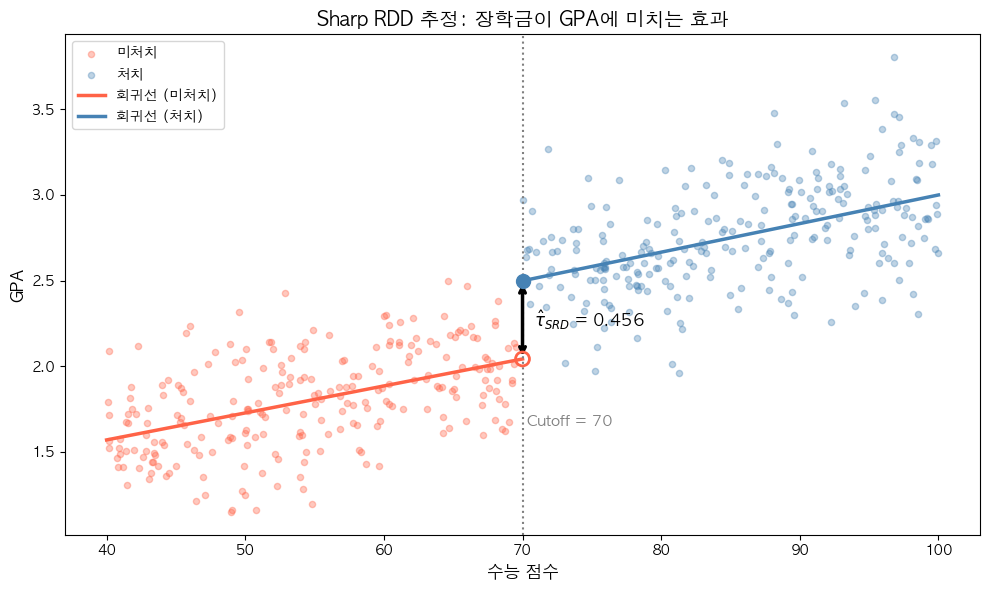

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

left  = df[df['treated'] == 0]
right = df[df['treated'] == 1]

ax.scatter(left['score'],  left['gpa'],  color='tomato',    alpha=0.35, s=20, label='미처치')
ax.scatter(right['score'], right['gpa'], color='steelblue', alpha=0.35, s=20, label='처치')

s_left  = np.linspace(40, cutoff, 100)
s_right = np.linspace(cutoff, 100, 100)
ax.plot(s_left,  model_left.predict(pd.DataFrame({'score_c': s_left  - cutoff})), color='tomato',    linewidth=2.5, label='회귀선 (미처치)')
ax.plot(s_right, model_right.predict(pd.DataFrame({'score_c': s_right - cutoff})), color='steelblue', linewidth=2.5, label='회귀선 (처치)')

ax.scatter([cutoff], [y_at_c_left],  s=100, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_at_c_right], s=100, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_at_c_right), xytext=(cutoff, y_at_c_left),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))
ax.text(cutoff + 0.8, (y_at_c_left + y_at_c_right) / 2,
        f'$\\hat{{\\tau}}_{{SRD}}$ = {estimated_effect:.3f}',
        fontsize=12, va='center', fontweight='bold')

ax.axvline(cutoff, color='gray', linestyle=':', linewidth=1.5)
ax.text(cutoff + 0.3, 1.65, f'Cutoff = {cutoff}', fontsize=11, color='gray')

ax.set_title('Sharp RDD 추정: 장학금이 GPA에 미치는 효과', fontsize=14, fontweight='bold')
ax.set_xlabel('수능 점수', fontsize=12)
ax.set_ylabel('GPA', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 기타.

RDD를 적용할 때 자주 마주치는 오해와, 분석 전에 반드시 확인해야 할 것들을 정리합니다.

### 흔한 오해들

"기준점 근방만 보면 된다"는 말은 맞지만, **얼마나 가까운 범위**를 써야 하는지는 임의로 정할 수 없습니다. 너무 좁으면 데이터가 부족해 분산이 커지고, 너무 넓으면 기준점에서 멀리 떨어진 개체들이 섞여 편의가 생깁니다. 이 범위를 **bandwidth** 라 하며, 최적 bandwidth는 별도의 알고리즘(Imbens & Kalyanaraman, 2012)으로 선택합니다.

"RDD는 무작위 실험과 동일하다"는 것도 정확하지 않습니다. 기준점 *근방*에서만 준무작위화가 성립합니다. 기준점에서 멀리 떨어진 집단에 대한 효과는 추정하지 않으며, 외부 타당성(external validity)이 낮을 수 있다는 점을 인식해야 합니다.

### Validity 체크: McCrary Density Test

가장 중요한 체크는 **조작(manipulation) 여부** 입니다. McCrary(2008)가 제안한 방법은 간단합니다. Running variable의 분포가 기준점에서 연속인지 확인합니다.

만약 학생들이 70점을 목표로 의도적으로 점수를 관리하거나, 채점자가 특정 학생을 밀어준다면, 기준점 바로 위에 개체가 비정상적으로 몰릴 것입니다. 반대로 오른쪽에 몰리기를 피하려는 경우라면 왼쪽이 빌 수도 있습니다. 어느 경우든 히스토그램에서 기준점 근방의 갑작스러운 밀도 변화로 나타납니다.

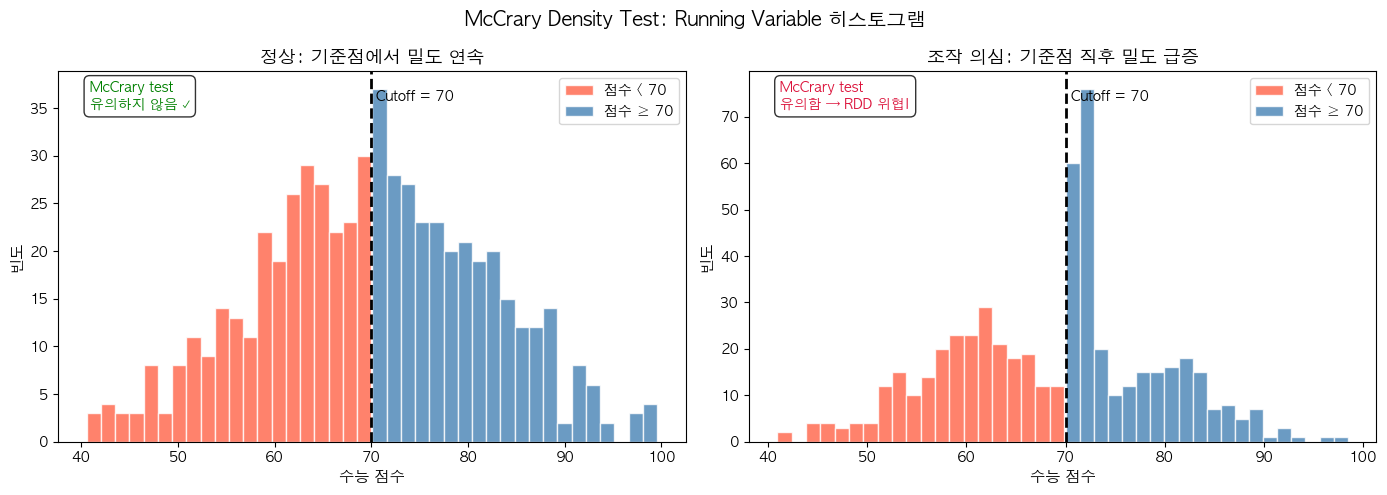

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 왼쪽: 조작 없음 ──
ax = axes[0]
score_clean = np.random.normal(70, 12, 600)
score_clean = score_clean[(score_clean >= 40) & (score_clean <= 100)]

ax.hist(score_clean[score_clean <  cutoff], bins=20, color='tomato',    edgecolor='white', alpha=0.8, label='점수 < 70')
ax.hist(score_clean[score_clean >= cutoff], bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='점수 ≥ 70')
ax.axvline(cutoff, color='black', linestyle='--', linewidth=2)
ax.text(cutoff + 0.5, ax.get_ylim()[1] * 0.92, f'Cutoff = {cutoff}', fontsize=10, color='black')
ax.set_title('정상: 기준점에서 밀도 연속', fontsize=13, fontweight='bold')
ax.set_xlabel('수능 점수', fontsize=11)
ax.set_ylabel('빈도', fontsize=11)
ax.legend(fontsize=10)
ax.text(0.05, 0.90, 'McCrary test\n유의하지 않음 ✓', transform=ax.transAxes,
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# ── 오른쪽: 조작 의심 ──
ax2 = axes[1]
score_below = np.random.normal(62, 8, 300)
score_below = score_below[(score_below >= 40) & (score_below < cutoff)]
score_above = np.concatenate([
    np.random.normal(78, 7, 200),
    np.random.uniform(70, 73, 120)  # 기준점 직후에 비정상적으로 몰린 개체들
])
score_above = score_above[(score_above >= cutoff) & (score_above <= 100)]

ax2.hist(score_below, bins=20, color='tomato',    edgecolor='white', alpha=0.8, label='점수 < 70')
ax2.hist(score_above, bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='점수 ≥ 70')
ax2.axvline(cutoff, color='black', linestyle='--', linewidth=2)
ax2.text(cutoff + 0.5, ax2.get_ylim()[1] * 0.92, f'Cutoff = {cutoff}', fontsize=10, color='black')
ax2.set_title('조작 의심: 기준점 직후 밀도 급증', fontsize=13, fontweight='bold')
ax2.set_xlabel('수능 점수', fontsize=11)
ax2.set_ylabel('빈도', fontsize=11)
ax2.legend(fontsize=10)
ax2.text(0.05, 0.90, 'McCrary test\n유의함 → RDD 위협!', transform=ax2.transAxes,
         fontsize=10, color='crimson', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.suptitle('McCrary Density Test: Running Variable 히스토그램', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 그 외 타당성 검정들

McCrary test 외에도 분석 전에 확인할 것들이 있습니다.

**공변량 연속성 검정**은 처치와 무관한 공변량(성별, 부모 소득 등)을 outcome 삼아 RDD를 실행해보는 것입니다. 기준점에서 공변량이 불연속이면 처치 효과 추정에 혼입이 의심됩니다. 당연히 이 경우엔 점프가 없어야 합니다.

**Placebo cutoff test**는 실제 기준점이 아닌 다른 지점(예: 60점, 80점)에서 RDD를 돌려보는 것입니다. 가짜 기준점에서는 불연속이 나타나지 않아야 합니다.

**Donut hole test**는 기준점 바로 근방(예: ±2점) 관측치를 제외하고 분석하는 방법입니다. 결과가 크게 바뀐다면 그 근방에 뭔가 수상한 점이 있다는 신호입니다.

| 검정 | 목적 | 기대 결과 |
|------|------|----------|
| **McCrary density test** | Running variable 조작 여부 | 기준점에서 밀도 연속 |
| **공변량 연속성** | 다른 요인이 기준점과 무관한지 | 공변량의 점프 = 0 |
| **Placebo cutoff** | 기준점 외 지점에서는 불연속 없어야 | 가짜 기준점 효과 = 0 |
| **Donut hole** | 기준점 근방 조작에 강건한지 | 제외해도 추정값 유사 |

## 참고 자료

- [인과추론의 데이터과학 (Youtube)](https://www.youtube.com/watch?v=8SIoMJTmO3A)
- Imbens, G. W., & Lemieux, T. (2008). Regression discontinuity designs: A guide to practice. *Journal of Econometrics*, 142(2), 615–635.
- McCrary, J. (2008). Manipulation of the running variable in the regression discontinuity design: A density test. *Journal of Econometrics*, 142(2), 698–714.
- Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2019). *A Practical Introduction to Regression Discontinuity Designs*. Cambridge University Press.